# Multiple curve plotting and fitting

In this example, we will demonstrate how to plot and fit multiple curves using the `ramanpl` library. This is particularly useful for analyzing Raman and photoluminescence spectra from 2D materials. 

## Raman example
In the following example, we will demonstrate the plotting of WS2 Raman spectra collected from different morphologies fabricated under various temperature conditions.

Expt setting:
- Sampling site: on different WS2 morphology fabricated under different CVD conditions
- Exposure time: 1s
- Laser Power: 1%
- magnification: 100x
- Accumulation: 3
- Laser setting: central $\lambda$ = 520 cm^-1 ; laser = `532`nm ; grating: 1800 vis

### Example of quick multi-plotting

First is the overlay plot of multiple spectra:

```python
        from ramanpl.batch import load_spectra, plot_overlay

        files = [
            "path/to/point1.txt",
            "path/to/point2.txt",
            "path/to/point3.txt",
            "path/to/point4.txt",
        ]

        specs = load_spectra(files, axis="wavenumber")  # or axis="energy" for PL data
        fig, ax = plot_overlay(specs, 
        normalise="max", # options: if set "none", no normalisation
        title="Overlay comparison", 
        xlim=(200, 800)         # set x-axis limits, or x_range=(200, 800)
        )
```

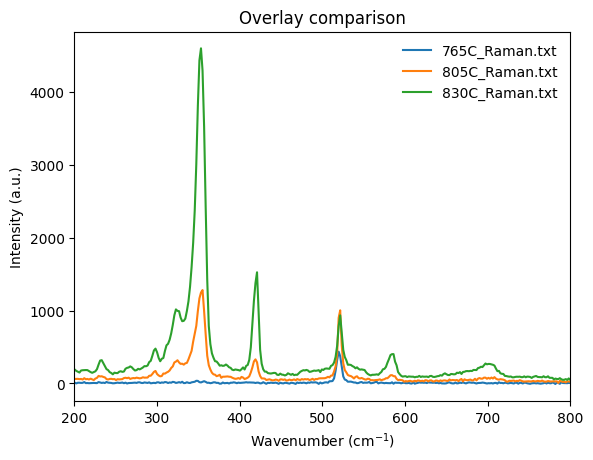

In [1]:
from ramanpl.batch import load_spectra, plot_overlay

files = [
    "765C_Raman.txt",
    "805C_Raman.txt",
    "830C_Raman.txt",
]

specs = load_spectra(files, axis="wavenumber")  # or axis="energy" for PL data
fig, ax = plot_overlay(specs, normalise="none", title="Overlay comparison", x_range=(200, 800))


You can also plot them in a waterfall style:

```python
        from ramanpl.batch import plot_waterfall
        files = [
            "path/to/point1.txt",
            "path/to/point2.txt",
            "path/to/point3.txt",
            "path/to/point4.txt",
        ]

        specs = load_spectra(files, axis="wavenumber")  # or axis="energy"
        fig, ax = plot_waterfall(specs, 
        normalise="max", 
        offset=1.0,         # vertical offset between spectra
        title="Waterfall comparison", 
        xlim=(200, 800)        # set x-axis limits
        )
```

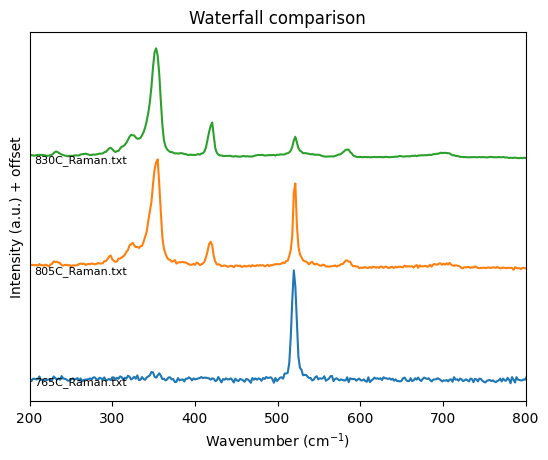

In [2]:
from ramanpl.batch import plot_waterfall

fig, ax = plot_waterfall(specs, normalise="max", offset=1.0, title="Waterfall comparison", xlim=(200, 800))


### Example of fitted plots

You can also overlay the fitted curves along with the raw data by setting the `y_select` parameter to `"fit"` or `"raw+fit"` in the `plot_overlay` function. But it will need to be done by importing the class modules `RamanBatch`:

```python

    from ramanpl.batch import RamanBatch
    
    files = [
            "path/to/point1.txt",   # or .wdf
            "path/to/point2.txt",
            "path/to/point3.txt",
            "path/to/point4.txt",
            ]

    specs = load_spectra(files, axis="wavenumber")

    b = RamanBatch(
        files,
        materials=["WS2"],      # specify the material for fitting, e.g. "WS2", "MoS2", etc.
        substrate="Si",         # specify substrate for background
        background_remove=True,
        baseline_method="arPLS",
    )

    b.fit()
    b.plot_overlay(normalise="max", raw_fit=True, title="Raman: raw + fit")
    b.plot_waterfall(normalise="max", raw_fit=True, offset=0.6, title="Raman waterfall")

```

**Additional tips**:
 you can also specify peaks and fitting-range for your batch processing. For example, you can use `custom_peaks` dictionaries to pass *all* the peaks you want to fit. 
 
 Or if you are happy with default library of peaks, but want to remove specific existing peak that does not exists, you can use `remove_peaks=['A1g']` when you set the options in the `RamanBatch` class.

D:\OneDrive - University of Cambridge\9 Expt results\Raman\00A_data_analysis_source code\RamanPL_2D\src\ramanpl\baselineAPI.py:354: RuntimeWarning: overflow encountered in exp
  w = 1.0 / (1.0 + np.exp(2.0 * (d - (2.0 * sigma - mu)) / sigma))


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Raman waterfall'}, xlabel='Wavenumber (cm$^{-1}$)', ylabel='Intensity (a.u.) + offset'>)

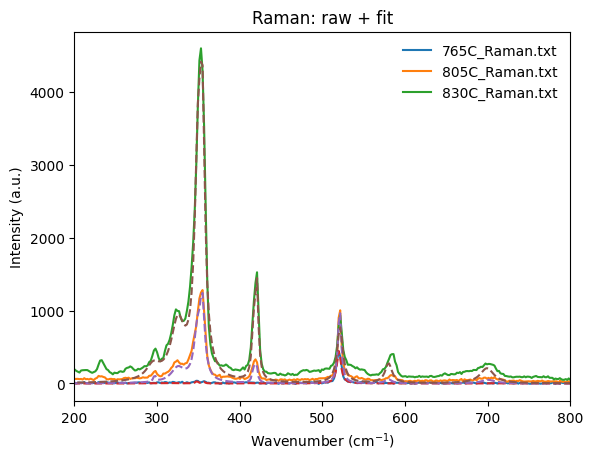

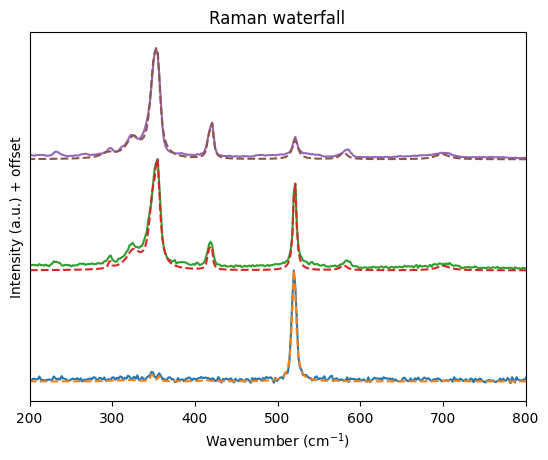

In [3]:
from ramanpl.batch import RamanBatch

files = ["765C_Raman.txt", "805C_Raman.txt", "830C_Raman.txt"]

b = RamanBatch(
    files,
    materials=["WS2"],
    substrate="Si",
    background_remove=True,
    baseline_method="arPLS",
    # custom_peaks=custom_peaks,
    remove_peaks=['A1g(M)+LA(M)','A1g(M)-LA(M)','LA(M)'],
    # peak_profile="pvoigt",      # select fitting model, "lorentzian" and "pvoigt"
)

b.fit()
b.plot_overlay(normalise="none", raw_fit=True, title="Raman: raw + fit",x_range=(200, 800))
b.plot_waterfall(normalise="max", raw_fit=True, offset=1.0, title="Raman waterfall",x_range=(200, 800))



0.011034090842198944 11


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Raman waterfall'}, xlabel='Wavenumber (cm$^{-1}$)', ylabel='Intensity (a.u.) + offset'>)

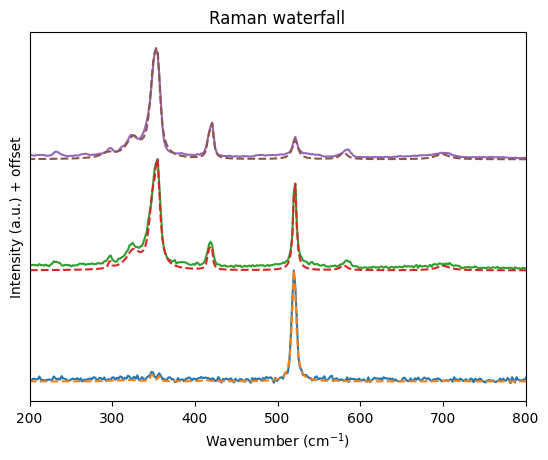

In [4]:
# Inspect one fitter’s diagnostics
raw, fit, fitter = b.fits[0]
print(fitter.fit_diagnostics["rmse"], fitter.fit_diagnostics["n_params_at_bounds"])
b.plot_waterfall(normalise="max", raw_fit=True, offset=1.0, title="Raman waterfall",x_range=(200, 800))

### Batch Raman fitting with explicit preprocessing *Pipeline*

In the version later than v0.3.5, you can also specify a custom preprocessing pipeline for your batch fitting.

This example uses the new `preprocessing=Pipeline(...)` workflow instead of the legacy
`smoothing=True` / `background_remove=True` flags.

The preprocessing chain here is:
1. crop to 200–800 cm $^{-1}$
2. Savitzky–Golay smoothing
3. arPLS baseline subtraction

Note: fitting normalisation is still handled internally by `RamanFit`; plot normalisation
is controlled separately in `plot_overlay(...)` and `plot_waterfall(...)`.

```python

# Example preprocessing pipeline:
# 1) crop to Raman window of interest
# 2) smooth with Savitzky–Golay
# 3) subtract baseline using arPLS
raman_preprocess = Pipeline(
    steps=[
        CropByRange((200, 800)),
        SmoothSavGol(window_length=11, polyorder=3),
        BaselineSubtract(
            baseline_spec={
                "method": "arpls",
                "lam": 1e6,
                "niter": 50,
                "tol": 1e-6,
            },
            clip_nonnegative=True,
        ),
    ],
    name="raman_crop_smooth_arpls",
)

```

D:\OneDrive - University of Cambridge\9 Expt results\Raman\00A_data_analysis_source code\RamanPL_2D\src\ramanpl\baselineAPI.py:354: RuntimeWarning: overflow encountered in exp
  w = 1.0 / (1.0 + np.exp(2.0 * (d - (2.0 * sigma - mu)) / sigma))


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Raman waterfall'}, xlabel='Wavenumber (cm$^{-1}$)', ylabel='Intensity (a.u.) + offset'>)

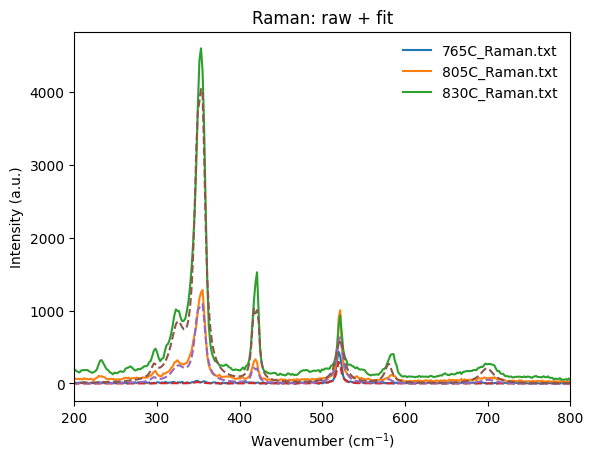

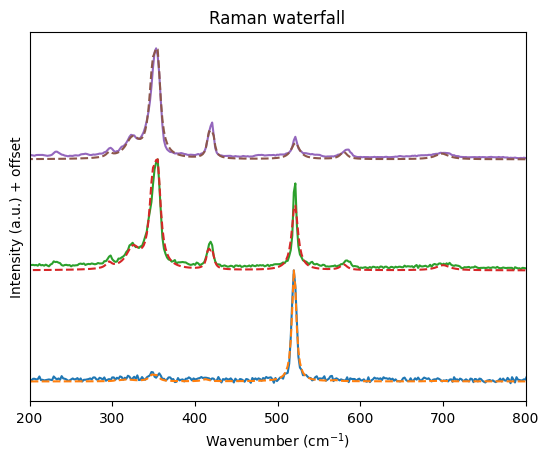

In [5]:
from ramanpl.batch import RamanBatch
from ramanpl.preprocessing import Pipeline, CropByRange, SmoothSavGol, BaselineSubtract

files = ["765C_Raman.txt", "805C_Raman.txt", "830C_Raman.txt"]

pipeline = Pipeline(
    steps=[
        CropByRange((200, 800)),
        SmoothSavGol(window_length=11, polyorder=3),
        BaselineSubtract(baseline_spec="arpls", clip_nonnegative=True),
    ],
    name="crop_smooth_arpls",
)

b = RamanBatch(
    files,
    materials=["WS2"],
    substrate="Si",
    preprocessing=pipeline,
    background_remove=False,
    smoothing=False,
    remove_peaks=['A1g(M)+LA(M)', 'A1g(M)-LA(M)', 'LA(M)'],
)

b.fit()
b.plot_overlay(normalise="none", raw_fit=True, title="Raman: raw + fit", x_range=(200, 800))
b.plot_waterfall(normalise="max", raw_fit=True, offset=1.0, title="Raman waterfall", x_range=(200, 800))

### Summary statistics of fitted parameters across multiple spectra

You can also use the built-in `summary_by_peak()` method to analyse the statistics of the fitted peak parameters across multiple spectra, which can be useful for understanding trends and variations in the data.

1. Block-style printing to terminal (no export)

```python
    summary = b.summary_by_peak(print_mode="blocks", interval=(0.05, 0.95), show_minmax_in_blocks=True)
```

2. Block-style printing with CSV export

```python
    summary = b.summary_by_peak(print_mode="blocks", export_path="summary.csv")
```

3. Keep table printing, and still export to CSV

```python
    summary = b.summary_by_peak(print_mode="table", export_path="summary.csv")
```

In [6]:
summary = b.summary_by_peak(print_mode="blocks", interval=(0.05, 0.95), show_minmax_in_blocks=True)


E12g
----
  position   n=3 | mean±std 354.614 ± 0.708442 | median 354.917 | q05–q95 353.916–355.101 | min–max 353.805–355.121
  fwhm       n=3 | mean±std 8.09942 ± 0.579775 | median 8.29481 | q05–q95 7.53195–8.53011 | min–max 7.44719–8.55625
  peak_height n=3 | mean±std 1235.28 ± 1504.24 | median 780.433 | q05–q95 87.8986–2701.05 | min–max 10.9504–2914.46

A1g
---
  position   n=3 | mean±std 420.222 ± 1.96046 | median 420.956 | q05–q95 418.296–421.634 | min–max 418–421.709
  fwhm       n=3 | mean±std 6.84434 ± 2.48955 | median 5.41151 | q05–q95 5.40339–9.28827 | min–max 5.40249–9.71902
  peak_height n=3 | mean±std 309.828 ± 409.828 | median 154.962 | q05–q95 15.4962–712.567 | min–max 3.77584e-12–774.523

2LA(M)
------
  position   n=3 | mean±std 348.611 ± 0.532119 | median 348.859 | q05–q95 348.086–348.962 | min–max 348–348.974
  fwhm       n=3 | mean±std 9.64691 ± 0.611564 | median 10 | q05–q95 9.04667–10 | min–max 8.94074–10
  peak_height n=3 | mean±std 1116.18 ± 1355.24 | median 70

And a more user-friendly display would be the *"wide"* tables. You can do it by the code such as this:

**(RECOMENDED)** Use the class module:

```python
    from ramanpl.batch import RamanBatch, pivot_parameters

    b = RamanBatch(...)  # as above

     wide = b.wide_table()

```

Or use the function `pivot_parameters` directly:

```python
    from ramanpl.batch import pivot_parameters

    wide = pivot_parameters(df)   # df = parameters_dataframe(rows)
    wide
```

In [7]:
import re

# Optional: add temperature column parsed from filename
def parse_temp(s):
    m = re.search(r"(\d+)\s*C", str(s))
    return float(m.group(1))

wide = b.wide_table(add_condition=True, 
                    condition_name="temperature_C",     # name of new column
                    condition=parse_temp,   # name of function to parse from source 
                    sort_by_condition=True              # sort by new column
                    )
wide

,2LA(M)-2E22g_fwhm,2LA(M)-2E22g_peak_height,2LA(M)-2E22g_position,2LA(M)-E22g_fwhm,2LA(M)-E22g_peak_height,2LA(M)-E22g_position,2LA(M)_fwhm,2LA(M)_peak_height,2LA(M)_position,3LA(K)_fwhm,...,B1/u_fwhm,B1/u_peak_height,B1/u_position,E12g_fwhm,E12g_peak_height,E12g_position,Si_fwhm,Si_peak_height,Si_position,temperature_C
source,,,,,,,,,,,,,,,,,,,,,
765C_Raman.txt,3.628718,2.651574,305.000000,18.796215,4.749720,318.553311,8.940741,14.418198,348.000000,10.0,...,10.000000,5.365810,413.000000,7.447188,10.950413,353.804827,6.225427,302.178324,520.109794,765.0
805C_Raman.txt,8.284324,55.792289,296.014273,20.000000,201.101234,325.034832,10.000000,704.617164,348.973705,10.0,...,5.440462,166.978884,416.230450,8.556249,780.432590,355.121270,9.139281,642.041506,520.958665,805.0
830C_Raman.txt,8.061226,162.500359,296.259925,20.000000,685.440971,324.450504,10.000000,2629.490822,348.858841,10.0,...,5.770094,801.518272,416.949013,8.294810,2914.456629,354.916815,12.081046,591.334302,521.518050,830.0


### Data export
**(Recomended)** You can use class module ways again, cleanly:

```python

    from ramanpl.batch import RamanBatch

    b = RamanBatch(...)  # as above

    b.export("filename.csv")

```

Or you can even export the fitted data and metadata to CSV or TXT files using the `export_dataframe` function:

```python

    from ramanpl.batch import pivot_parameters, export_table
    export_table(
        wide,
        "raman_fit_wide.csv",
        fits_with_fitters=fits,
        metadata={"x_axis": "your_x_axis_info"}, # such as units or experimental conditions
        meta_in_csv=True,       # write # comment metadata even in CSV
        float_format="%.6g",
    )

```

In [8]:

b.export("raman_fit_wide.csv", 
         wide=True, 
         add_condition=True, 
         condition=parse_temp
         )


'raman_fit_wide.csv'

### Example of plot for fitted paramter plots
Next, you can use the fitted parameters to plot the change in the Raman peak positions, FWHM, and intensities across different samples:

1. Default: x-axis = file names (no condition needed)

```python

    from ramanpl.batch import plot_fitted_parameters
    import pandas as pd
    
    df_r = b_raman.to_dataframe()   # pandas DataFrame created internally

    # Position
    plot_fitted_parameters(
        df_r,
        metric="position",          # or "fwhm", "intensity"
        peaks=["E12g", "A1g"],
        title="Raman peak positions",
        ylabel="Position (cm$^{-1}$)",
    )

```

2. Alternatively, you can define x-axis condition (e.g. temperature) by providing a list/array of conditions (most beginner-friendly)

```python

    temps = [765, 805, 830]
    b_raman.plot_parameters(
        metric="intensity",
        peaks=["E12g", "A1g"],
        x=temps,
        x_label="Temperature (°C)",
        title="Raman intensity vs temperature",
    )

```

3. Or provide a function (power-user / pattern-based)

```python

    def pressure_from_name(src: str):
    # user-defined parsing logic
    ...

    b_pl.plot_parameters(metric="fwhm", peaks=["exciton","trion"], x=pressure_from_name,
                     x_label="Pressure (mbar)", title="PL FWHM vs pressure")
```



(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Raman FWHM vs Temperature'}, xlabel='Condition', ylabel='FWHM (cm$^{-1}$)'>)

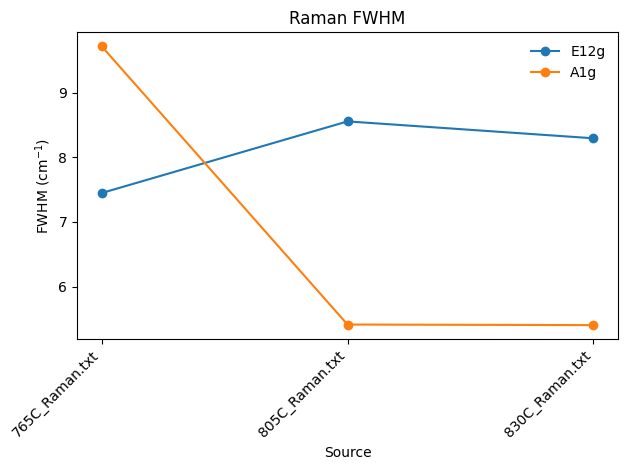

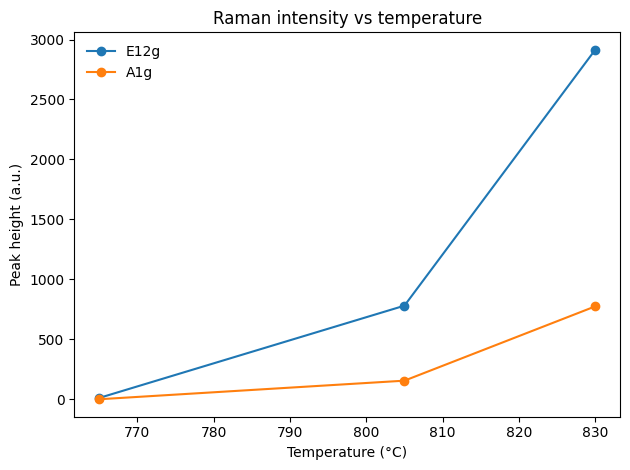

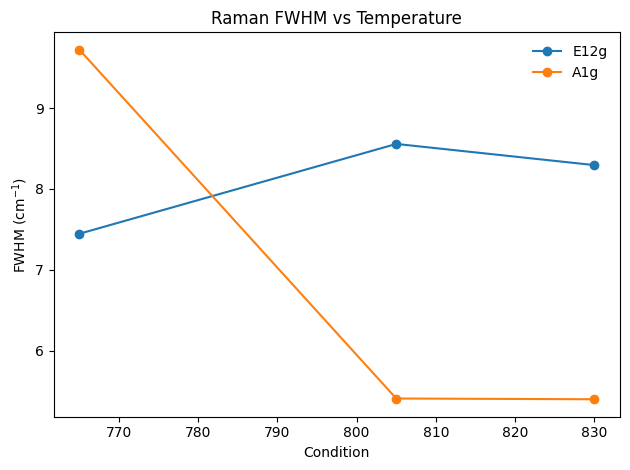

In [9]:
from ramanpl.batch import plot_fitted_parameters

# Run b.fit() first as above

# Directly plot from RamanBatch object
b.plot_parameters(metric="fwhm", peaks=["E12g", "A1g"], title="Raman FWHM")


## Alternatively, you can define x-axis condition (e.g. temperature)
temps = [765, 805, 830]
b.plot_parameters(
    metric="peak_height",
    peaks=["E12g", "A1g"],
    x=temps,
    x_label="Temperature (°C)",
    title="Raman intensity vs temperature",
)


# Or plot from a user-defined logic
import re

def cond_from_source(s):
    # Example: "765C_Raman.txt" -> 765
    m = re.search(r"(\d+)\s*C", str(s))
    if not m:
        raise ValueError(f"Cannot parse condition from source: {s}")
    return float(m.group(1))

b.plot_parameters(metric="fwhm", peaks=["E12g","A1g"], x=cond_from_source,
                     x_label="Temperature (°C)", title="Raman FWHM vs Temperature")

--------
## PL example

In the following example, we will demonstrate the plotting of WS2 photoluminescence spectra collected from different morphologies fabricated under various temperature conditions.

Expt setting:
- Sampling site: same as Raman
- Exposure time: 0.1s
- Laser Power: 1%
- magnification: 100x
- Accumulation: 3
- Central wavelength: 1.93eV
- Laser setting: `532nm` ; grating: `1800 vis`

### Example of plotting

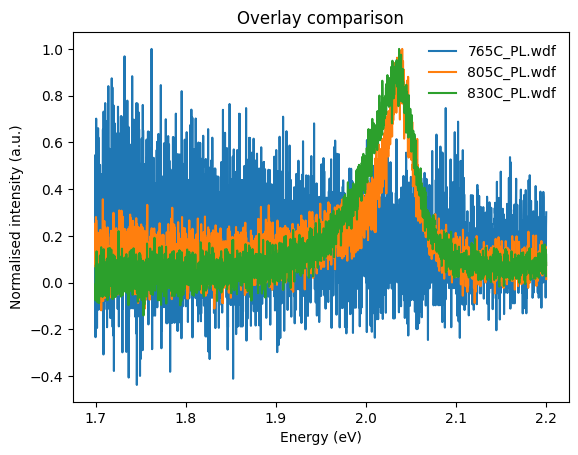

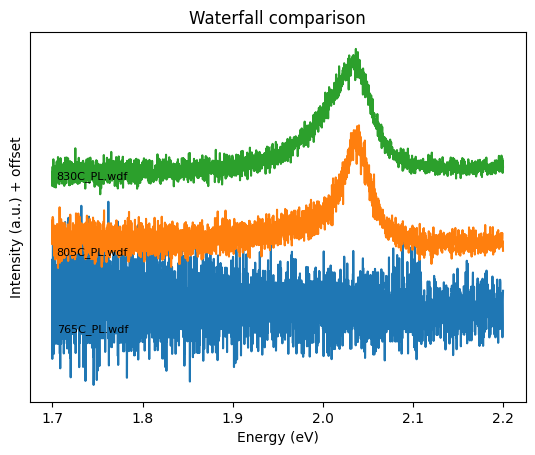

In [10]:
### Overlay plot for PL data
from ramanpl.batch import load_spectra, plot_overlay

files = [
    "765C_PL.wdf",
    "805C_PL.wdf",
    "830C_PL.wdf",
]

specs = load_spectra(files, axis="energy")
fig, ax = plot_overlay(specs, normalise="max", title="Overlay comparison")


### waterfall plot
from ramanpl.batch import plot_waterfall

fig1, ax1= plot_waterfall(specs, normalise="max", offset=0.6, title="Waterfall comparison")


### Example of fitted plots
**(Recomended)** You can fit the PL spectra using the `PLBatch` class module:

```python
    from ramanpl.batch import PLBatch

    files = [
            "path/to/point1.wdf",
            "path/to/point2.wdf",
            "path/to/point3.wdf",
            "path/to/point4.wdf",
        ]

    b = PLBatch(
        files,
        background_remove=True,
        baseline_method="arPLS",
        smoothing=False,
    )

    b.fit()
    b.plot_overlay(normalise="max", raw_fit=True, title="PL: raw + fit")
    b.plot_waterfall(normalise="max", raw_fit=True, offset=1.0, title="PL waterfall")

```


Or you can also plot fitted curve of the PL spectra in an overlay style:

```python
        from ramanpl.batch import load_spectra, plot_overlay

        files = [
            "path/to/point1.wdf",
            "path/to/point2.wdf",
            "path/to/point3.wdf",
            "path/to/point4.wdf",
        ]

        specs = load_spectra(files, axis="energy")  # or axis="wavenumber" for Raman data
        fig, ax = plot_overlay(specs, normalise="max", title="Overlay comparison")
```


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'PL: raw + fit'}, xlabel='Energy (eV)', ylabel='Intensity (a.u.) + offset'>)

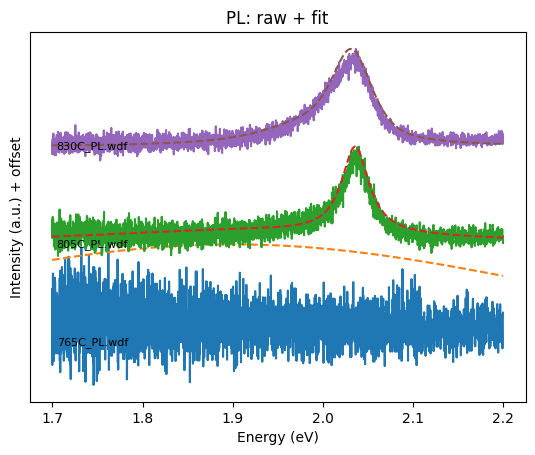

In [11]:
from ramanpl.batch import PLBatch

files = ["765C_PL.wdf", "805C_PL.wdf", "830C_PL.wdf"]

custom_peaks = {
    "Trion":   ([1.90, 0.01, 0, 0.0], [1.98, 0.80, 5, 0.99]),
    "Exciton": ([1.97, 0.01, 0, 0.0], [2.07, 0.80, 10, 0.99]),
}


b_pl = PLBatch(
    files,
    background_remove=False,
    # baseline_method="arPLS",  # set it if you want specific baseline removal
    smoothing=False,
    custom_peaks=custom_peaks,
    peak_profile="pvoigt",      # select fitting model, "lorentzian" and "pvoigt"
)

b_pl.fit()     ## perform fitting
b_pl.plot_waterfall(normalise="max", raw_fit=True, title="PL: raw + fit")

**(Optional)** You can also view your wide table or export the data as per Raman example aboove:

```python
    from ramanpl.batch import PLBatch
    b = PLBatch(...)  # as above
    b.export("pl_fitted_paramters.csv")
```

### Example of plot for fitted paramter plots

Similarly, you can plotted fitted parameters such as peak positions, FWHM, and intensities across different samples using the `plot_fitted_parameters` function.
```python
    from ramanpl.batch import plot_fitted_parameters

    # b_pl is your PLBatch instance, already fitted:
    # b_pl.fit()

    temps = [765, 805, 830]
    b_pl.plot_parameters(
    metric="intensity",
    peaks=["exciton", "trion"],
    x=temps,
    x_label="Temperature (°C)",
    title="PL intensity vs temperature",
    )
```


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'PL intensity vs temperature'}, xlabel='Temperature (°C)', ylabel='Peak height (a.u.)'>)

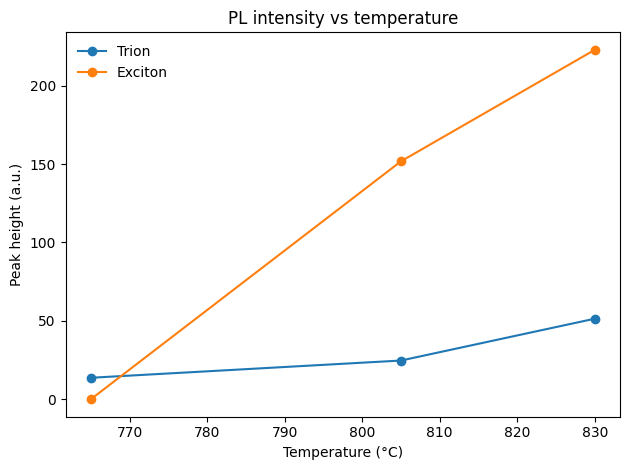

In [13]:
# b_pl is your PLBatch instance, already fitted:
# b_pl.fit()

temps = [765, 805, 830]
b_pl.plot_parameters(
metric="peak_height",
peaks=["Exciton", "Trion"],
x=temps,
x_label="Temperature (°C)",
title="PL intensity vs temperature",
)
